# k vecinos más cercanos (k-NN)

> Cómo clasificar o predecir un valor mirando a los $k$ ejemplos de entrenamiento más parecidos, sin ajustar ningún modelo. Se explican la votación y la media de vecinos, la elección de $k$ y de la distancia, y los límites del método: escala, alta dimensión, coste y extrapolación.
>
> **Requisitos previos:** [Flujo de ML y evaluación](01-flujo-ml-y-evaluacion.ipynb) · [distancias y escalado](../03-preparacion-datos/05-distancias-y-similitud.ipynb) · **Relacionado:** [clustering por densidad](06-clustering-densidad.ipynb) · [árboles de decisión](08-arboles-decision.ipynb) · [SVM](09-svm.ipynb)

## 1. Idea clave

**k-NN** predice la clase (o el valor) de un punto nuevo a partir de los $k$ puntos de entrenamiento más cercanos: en clasificación, **vota** la clase mayoritaria entre ellos, y en regresión, promedia sus valores. Se basa en una idea sencilla: *puntos parecidos tienen resultados parecidos*.

Es un método **basado en instancias** o de **aprendizaje perezoso** (*lazy learning*): no hay fase de entrenamiento que construya un modelo, solo se guardan los datos. El trabajo ocurre al predecir, cuando hay que buscar los vecinos de cada punto nuevo. De ahí salen sus ventajas (cero entrenamiento, fronteras flexibles, un solo hiperparámetro importante) y sus límites: depende por completo de la **distancia** (hay que escalar), degrada en **alta dimensión**, **predecir es caro** con muchos datos y **no extrapola**.

Úsalo como línea base rápida con pocas variables bien escaladas y un conjunto de datos pequeño o mediano. Evítalo con muchas variables irrelevantes, con millones de filas o si necesitas predecir fuera del rango de los datos.

## 2. Conceptos importantes

### 2.1. Votación y media de vecinos

Sea $N_k(\mathbf{x})$ el conjunto de los $k$ puntos de entrenamiento más cercanos a $\mathbf{x}$ según una distancia $d$. En **clasificación**, la clase predicha es la que más peso suma entre sus vecinos:

$$
\hat{y}(\mathbf{x}) = \arg\max_{c} \sum_{i \in N_k(\mathbf{x})} w_i \, \mathbb{1}[y_i = c]
$$

donde $y_i$ es la clase del vecino $i$, $\mathbb{1}[\cdot]$ vale 1 si la condición se cumple y 0 si no, y $w_i$ es el peso del vecino. Con pesos **uniformes**, $w_i = 1$ (voto simple); con pesos **por distancia**, $w_i = 1/d(\mathbf{x}, \mathbf{x}_i)$, y los vecinos próximos cuentan más. En **regresión**, la predicción es la media ponderada de los valores de los vecinos:

$$
\hat{y}(\mathbf{x}) = \frac{\sum_{i \in N_k(\mathbf{x})} w_i\, y_i}{\sum_{i \in N_k(\mathbf{x})} w_i}
$$

### 2.2. La distancia

Todo el método descansa en $d$. Las más usadas, que se estudian con detalle en [distancias y similitud](../03-preparacion-datos/05-distancias-y-similitud.ipynb):

- **Minkowski** de orden $p$: $d_p(\mathbf{a}, \mathbf{b}) = \bigl(\sum_j |a_j - b_j|^p\bigr)^{1/p}$. Con $p = 2$ es la **euclídea** (por defecto) y con $p = 1$, la **Manhattan**.
- **Coseno**: $1 - \frac{\mathbf{a} \cdot \mathbf{b}}{\lVert \mathbf{a} \rVert \lVert \mathbf{b} \rVert}$. Compara direcciones, no magnitudes (texto, *embeddings*).
- **Hamming**: número de atributos que difieren. Para variables binarias o categóricas.

Como las distancias suman diferencias entre atributos, **un atributo con una escala mayor decide casi solo**: hay que [estandarizar](../03-preparacion-datos/03-transformacion-datos.ipynb) antes.

### 2.3. Elegir $k$: sesgo y varianza

- Con $k$ **pequeño**, la frontera sigue cada detalle de los datos (incluido el ruido): poco sesgo y mucha varianza, es decir, **sobreajuste** (*overfitting*). Con $k = 1$, cada punto de entrenamiento es su propio vecino más cercano, así que el error en entrenamiento es cero.
- Con $k$ **grande**, la predicción promedia una zona muy amplia: la frontera se suaviza, sube el sesgo y aparece **subajuste** (*underfitting*). En el extremo $k = n$, se predice siempre la clase mayoritaria.

Se elige con [validación cruzada](01-flujo-ml-y-evaluacion.ipynb), buscando la zona donde el error de validación es mínimo y estable. En clasificación binaria conviene un $k$ **impar**, para evitar empates en la votación.

### 2.4. Coste y maldición de la dimensionalidad

- **Fuerza bruta**: predecir un punto cuesta $O(n \cdot d)$ (distancia a los $n$ puntos guardados en $d$ dimensiones). Para acelerarlo se organizan los datos en un árbol (*k-d tree*, *ball tree*), que en pocas dimensiones encuentra los vecinos en $O(\log n)$ por consulta.
- **Maldición de la dimensionalidad** (*curse of dimensionality*): al crecer $d$, las distancias entre puntos aleatorios se parecen cada vez más entre sí, y la noción de "el más cercano" pierde sentido. Además, los árboles dejan de ser eficientes y cada variable irrelevante añade ruido a la distancia.

## 3. Código

Usamos tres conjuntos: **breast cancer** (569 tumores, 30 medidas numéricas, clase benigno/maligno; se carga con `load_breast_cancer`, derivado del repositorio UCI) para clasificar; **lunas** con ruido (`make_moons`) para ver la frontera de decisión; y una **curva seno** con ruido para la regresión.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

### 3.1. Datos

Separamos un 20 % para el test final y fijamos una validación cruzada estratificada de 5 particiones, que usaremos para decidir. La clase 0 es **maligno** (212 casos) y la 1, **benigno** (357).

In [2]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
print(X.shape, y.value_counts().sort_index().to_dict())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Las escalas de las variables son muy distintas
X_train[["mean area", "mean radius", "mean smoothness"]].describe().loc[["min", "max"]].round(2)

(569, 30) {0: 212, 1: 357}


,mean area,mean radius,mean smoothness
min,143.5,6.98,0.06
max,2499.0,28.11,0.14


### 3.2. El escalado importa

Comparamos k-NN con $k = 5$ sobre los datos sin escalar y con un `Pipeline` que estandariza primero. En el `Pipeline`, el escalador se ajusta **solo con los datos de entrenamiento** de cada partición.

In [3]:
modelos = {
    "sin escalar": KNeighborsClassifier(n_neighbors=5),
    "estandarizado": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
}
pd.DataFrame({
    nombre: {
        "exactitud CV": cross_val_score(modelo, X_train, y_train, cv=cv).mean(),
        "exactitud test": modelo.fit(X_train, y_train).score(X_test, y_test),
    } for nombre, modelo in modelos.items()
}).T.round(3)

,exactitud CV,exactitud test
sin escalar,0.941,0.912
estandarizado,0.963,0.956


Estandarizar sube la exactitud en validación cruzada de ≈ 0,94 a ≈ 0,96, y en test, de ≈ 0,91 a ≈ 0,96. Sin escalar, el área media (cientos) domina la distancia y la suavidad (décimas) apenas cuenta.

### 3.3. Elegir $k$ con validación cruzada

Calculamos, para cada $k$ de 1 a 30, la exactitud media en validación cruzada (con su desviación entre particiones) y la exactitud en el propio entrenamiento.

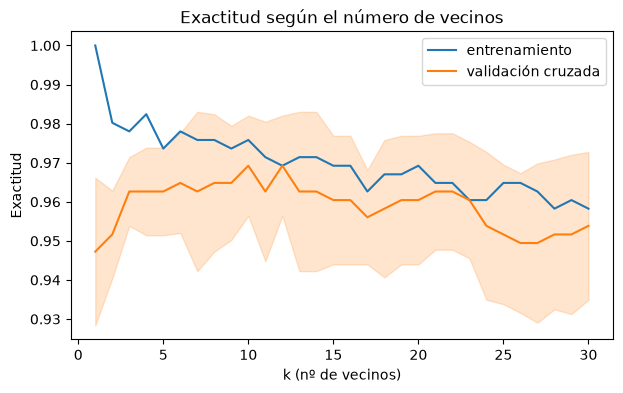

,cv_media,cv_std,entrenamiento
k,,,
1,0.947,0.019,1.000
2,0.952,0.011,0.980
3,0.963,0.009,0.978
5,0.963,0.011,0.974
10,0.969,0.013,0.976
15,0.960,0.016,0.969
21,0.963,0.015,0.965
30,0.954,0.019,0.958


In [4]:
modelo = make_pipeline(StandardScaler(), KNeighborsClassifier())
filas = []
for k in range(1, 31):
    modelo.set_params(kneighborsclassifier__n_neighbors=k)
    puntuaciones = cross_val_score(modelo, X_train, y_train, cv=cv)
    filas.append({"k": k, "cv_media": puntuaciones.mean(), "cv_std": puntuaciones.std(),
                  "entrenamiento": modelo.fit(X_train, y_train).score(X_train, y_train)})
curva_k = pd.DataFrame(filas).set_index("k")

plt.figure(figsize=(7, 4))
plt.plot(curva_k.index, curva_k["entrenamiento"], label="entrenamiento")
plt.plot(curva_k.index, curva_k["cv_media"], label="validación cruzada")
plt.fill_between(curva_k.index, curva_k["cv_media"] - curva_k["cv_std"],
                 curva_k["cv_media"] + curva_k["cv_std"], color="tab:orange", alpha=0.2)
plt.title("Exactitud según el número de vecinos")
plt.xlabel("k (nº de vecinos)")
plt.ylabel("Exactitud")
plt.legend()
plt.show()

curva_k.loc[[1, 2, 3, 5, 10, 15, 21, 30]].round(3)

- Con $k = 1$ la exactitud en entrenamiento es **exactamente 1** (cada punto se predice a sí mismo), pero en validación cruzada es la más baja de la tabla. Medir sobre el entrenamiento no dice nada de la calidad real.
- Entre $k = 3$ y $k = 21$ la validación cruzada se mueve en una banda muy estrecha (≈ 0,956–0,969), del orden de la desviación entre particiones (≈ 0,01–0,02): **esos valores son equivalentes**. Con $k$ muy grande ($k = 30$), la curva empieza a bajar (subajuste).

`GridSearchCV` automatiza la búsqueda. Elige el máximo, aunque la diferencia con sus vecinos sea de ruido:

In [5]:
busqueda = GridSearchCV(modelo, {"kneighborsclassifier__n_neighbors": list(range(1, 31))}, cv=cv)
busqueda.fit(X_train, y_train)
k_cv = busqueda.best_params_["kneighborsclassifier__n_neighbors"]
print(f"k elegido por validación cruzada: {k_cv} (exactitud CV = {busqueda.best_score_:.3f})")

resultados = {}
for k in [2, k_cv]:
    modelo.set_params(kneighborsclassifier__n_neighbors=k).fit(X_train, y_train)
    matriz = confusion_matrix(y_test, modelo.predict(X_test))  # filas: real; columnas: predicho
    resultados[f"k = {k}"] = {
        "exactitud test": modelo.score(X_test, y_test),
        "malignos no detectados": matriz[0, 1],
        "benignos marcados como malignos": matriz[1, 0],
    }
pd.DataFrame.from_dict(resultados, orient="index").round(3)

k elegido por validación cruzada: 10 (exactitud CV = 0.969)


,exactitud test,malignos no detectados,benignos marcados como malignos
k = 2,0.930,2,6
k = 10,0.965,3,1


Con $k = 2$ (un valor par, que admite empates) la exactitud en test es menor que con $k = 10$, el valor elegido por validación cruzada (0,930 frente a 0,965). Pero ojo con **qué errores** se cometen: $k = 10$ gana porque casi elimina las falsas alarmas (1 frente a 6), aunque deja pasar un tumor maligno más (3 frente a 2). Aquí el coste de no detectar un tumor maligno es mayor que el de una falsa alarma, y la exactitud global no distingue entre ambos. Con solo 114 casos de test, una diferencia de uno o dos casos es ruido: **elige la métrica según el coste del error** (por ejemplo, la sensibilidad sobre la clase maligna) y no te quedes solo con la exactitud.

### 3.4. La frontera de decisión según $k$

En dos dimensiones se ve cómo $k$ controla la complejidad. Usamos lunas con mucho ruido (`noise=0.35`) y dibujamos la región que el modelo asigna a cada clase.

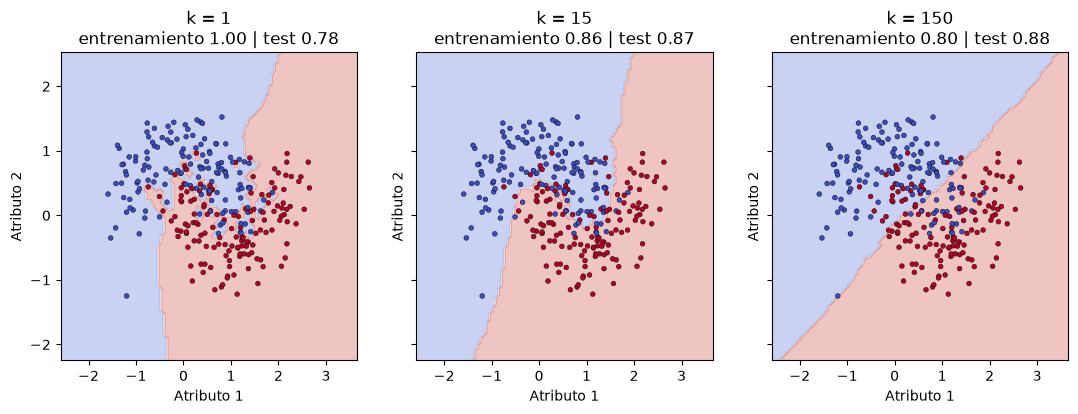

In [6]:
X_lunas, y_lunas = make_moons(n_samples=400, noise=0.35, random_state=42)
Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_lunas, y_lunas, test_size=0.3,
                                                         stratify=y_lunas, random_state=42)

fig, ejes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for eje, k in zip(ejes, [1, 15, 150]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xl_train, yl_train)
    DecisionBoundaryDisplay.from_estimator(knn, Xl_train, response_method="predict", cmap="coolwarm",
                                           alpha=0.3, ax=eje, xlabel="Atributo 1", ylabel="Atributo 2")
    eje.scatter(*Xl_train.T, c=yl_train, cmap="coolwarm", s=12, edgecolor="k", linewidth=0.3)
    eje.set_title(f"k = {k}\nentrenamiento {knn.score(Xl_train, yl_train):.2f} | test {knn.score(Xl_test, yl_test):.2f}")
plt.show()

Con $k = 1$ la frontera es irregular, con pequeñas islas alrededor de los puntos ruidosos: entrenamiento perfecto (1,00) y test mucho peor (0,78). Con $k = 15$ es más suave y sigue la forma de las lunas. Con $k = 150$ (más de la mitad de los 280 puntos de entrenamiento) la frontera se reduce a casi una recta y la exactitud en entrenamiento baja a 0,80: ya no hay vecindad local, solo una mayoría global. El test (0,88) no empeora aquí, pero con 120 puntos la diferencia con $k = 15$ (0,87) es ruido; lo que sí se ve es que la frontera ya no puede seguir la curva de las lunas.

### 3.5. Pesos y distancia

Probamos las dos formas de ponderar y tres distancias, con $k = 7$ y el `Pipeline` escalado:

In [7]:
filas = {}
for pesos in ["uniform", "distance"]:
    for metrica in ["euclidean", "manhattan", "cosine"]:
        modelo_d = make_pipeline(StandardScaler(),
                                 KNeighborsClassifier(n_neighbors=7, weights=pesos, metric=metrica, algorithm="brute"))
        filas[(pesos, metrica)] = cross_val_score(modelo_d, X_train, y_train, cv=cv).mean()
pd.Series(filas, name="exactitud CV").rename_axis(["pesos", "distancia"]).round(3).to_frame()

exactitud CV
pesos    distancia              
uniform  euclidean         0.963
         manhattan         0.967
         cosine            0.965
distance euclidean         0.963
         manhattan         0.967
         cosine            0.967

Las diferencias son de unas décimas de punto, por debajo de la desviación entre particiones: **en estos datos da igual**. En otros problemas (variables binarias, texto, clases desbalanceadas) sí importan, y conviene comprobarlo con validación cruzada en lugar de suponerlo.

### 3.6. Regresión y extrapolación

`KNeighborsRegressor` promedia los valores de los $k$ vecinos. Entrenamos con $x \in [0, 6]$ y predecimos hasta $x = 8$, fuera del rango visto:

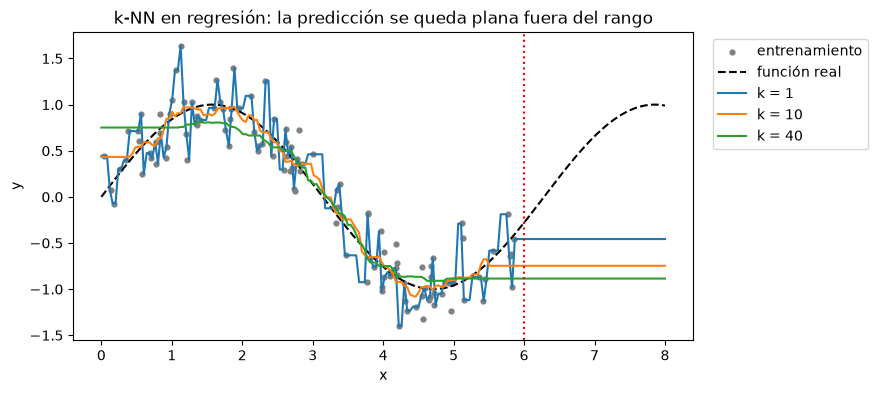

In [8]:
rng = np.random.default_rng(42)
x_train = np.sort(rng.uniform(0, 6, 120))
y_reg = np.sin(x_train) + rng.normal(0, 0.25, 120)
x_rejilla = np.linspace(0, 8, 200).reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.scatter(x_train, y_reg, s=12, color="gray", label="entrenamiento")
plt.plot(x_rejilla, np.sin(x_rejilla), "k--", label="función real")
for k in [1, 10, 40]:
    regresor = KNeighborsRegressor(n_neighbors=k).fit(x_train.reshape(-1, 1), y_reg)
    plt.plot(x_rejilla, regresor.predict(x_rejilla), label=f"k = {k}")
plt.axvline(6, color="red", linestyle=":")
plt.title("k-NN en regresión: la predicción se queda plana fuera del rango")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

Con $k = 1$ la curva sigue el ruido (escalones); con $k = 40$ se alisa tanto que pierde las subidas y bajadas del seno. Pasada la línea roja (fin de los datos), **todas las predicciones son constantes**, porque los $k$ vecinos más cercanos de cualquier $x > 6$ son siempre los mismos, los últimos puntos de entrenamiento. Esta limitación la comparten los [árboles de decisión](08-arboles-decision.ipynb) y se resuelve con modelos que tienen una forma funcional (como una regresión).

### 3.7. La maldición de la dimensionalidad

Dos demostraciones. Primero, añadimos al conjunto breast cancer $p$ columnas de ruido puro (ya con la misma escala tras estandarizar) y medimos la exactitud:

In [9]:
filas = {}
for p in [0, 10, 50, 200, 1000]:
    X_ruido = np.hstack([X, rng.normal(size=(len(X), p))])
    modelo_ruido = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7))
    filas[p] = cross_val_score(modelo_ruido, X_ruido, y, cv=cv).mean()
pd.Series(filas, name="exactitud CV").rename_axis("columnas de ruido añadidas").round(3).to_frame()

,exactitud CV
columnas de ruido añadidas,
0,0.965
10,0.954
50,0.935
200,0.921
1000,0.861


Cada columna irrelevante aporta ruido a las distancias. Con 30 atributos útiles y 1.000 de ruido, la exactitud cae del 0,96 a ≈ 0,86. Segundo, el **contraste de distancias** (cociente entre la distancia al punto más lejano y al más cercano de un punto cualquiera) entre 1.000 puntos aleatorios:

In [10]:
contraste = {}
for d in [2, 10, 100, 1000]:
    puntos = rng.uniform(size=(1000, d))
    consulta = rng.uniform(size=(1, d))
    dist = np.linalg.norm(puntos - consulta, axis=1)
    contraste[d] = dist.max() / dist.min()
pd.Series(contraste, name="más lejano / más cercano").rename_axis("dimensiones").round(1).to_frame()

,más lejano / más cercano
dimensiones,
2,102.0
10,3.2
100,1.4
1000,1.1


En 2 dimensiones, el vecino más lejano está unas 100 veces más allá que el más cercano. En 1.000, solo un 10 % más (cociente ≈ 1,1): todos los puntos quedan casi a la misma distancia y "el más cercano" apenas se distingue de cualquier otro. Las soluciones habituales son [seleccionar atributos](03-seleccion-atributos.ipynb) o [reducir la dimensión](02-reduccion-dimensionalidad.ipynb) antes de aplicar k-NN.

### 3.8. Coste de la predicción

Medimos cuánto tarda en predecir 1.000 puntos un modelo con 50.000 puntos de entrenamiento, según el algoritmo de búsqueda y la dimensión (los tiempos dependen de la máquina; importan las proporciones):

In [11]:
filas = {}
for d in [3, 50]:
    X_grande = rng.normal(size=(50_000, d))
    consultas = rng.normal(size=(1000, d))
    for algoritmo in ["brute", "kd_tree", "ball_tree"]:
        knn = KNeighborsClassifier(n_neighbors=5, algorithm=algoritmo).fit(X_grande, np.zeros(50_000, dtype=int))
        inicio = time.perf_counter()
        knn.predict(consultas)
        filas[(d, algoritmo)] = time.perf_counter() - inicio
pd.Series(filas, name="segundos").rename_axis(["dimensiones", "algoritmo"]).round(3).to_frame()

segundos
dimensiones algoritmo          
3           brute         0.037
            kd_tree       0.005
            ball_tree     0.046
50          brute         0.036
            kd_tree       5.314
            ball_tree     4.522

En 3 dimensiones el árbol *k-d* es varias veces más rápido que la fuerza bruta. En 50 dimensiones ocurre lo contrario: los árboles son **mucho más lentos** que la fuerza bruta (la maldición otra vez). Por eso `algorithm="auto"`, el valor por defecto, elige el método según los datos.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Clase | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `KNeighborsClassifier` / `KNeighborsRegressor` | `n_neighbors` | Nº de vecinos $k$ (5 por defecto) | Elígelo con validación cruzada; impar en clasificación binaria |
| | `weights` | `"uniform"` o `"distance"` | `"distance"` ayuda con clases desbalanceadas o densidades irregulares |
| | `metric`, `p` | Distancia (Minkowski con `p=2` por defecto) | Escala antes; `"cosine"` o `"manhattan"` según los datos; `"hamming"` para binarias |
| | `algorithm` | `"auto"`, `"brute"`, `"kd_tree"`, `"ball_tree"` | Deja `"auto"`; en alta dimensión la fuerza bruta suele ganar |
| | `n_jobs` | Paralelismo en la búsqueda | `-1` para usar todos los núcleos al predecir muchos puntos |
| `KNeighborsRegressor` | `n_neighbors` | Suavidad de la curva | $k$ pequeño sigue el ruido; $k$ grande alisa de más |

### 4.2. Errores comunes

**1. No escalar.** En la sección 3.2, estandarizar sube la exactitud del test del 0,91 al 0,96. Con atributos en unidades distintas (kilos y gramos, área y suavidad) la distancia es una medida sin sentido. Mete siempre el escalador en un `Pipeline`.

**2. Fijar $k$ de forma arbitraria, y peor, par.** Elegir $k = 2$ "porque sí" tiene dos problemas: nadie sabe si es un buen valor y, en clasificación binaria, el voto puede quedar **empatado**. Veamos qué hace scikit-learn en un empate:

In [12]:
X_mini = [[0], [1], [2], [3]]
for etiquetas in ([0, 0, 1, 1], [1, 1, 0, 0]):
    knn_mini = KNeighborsClassifier(n_neighbors=2).fit(X_mini, etiquetas)
    print(f"etiquetas {etiquetas} -> clase predicha para x = 1,5: {knn_mini.predict([[1.5]])[0]}")

etiquetas [0, 0, 1, 1] -> clase predicha para x = 1,5: 0
etiquetas [1, 1, 0, 0] -> clase predicha para x = 1,5: 0


Los dos vecinos de $x = 1{,}5$ son uno de cada clase en ambos casos, y **la predicción es siempre la clase 0**, sea cual sea su significado: se resuelve con la etiqueta de menor valor, no con ningún criterio. (La documentación avisa de un segundo efecto: con distancias idénticas entre el vecino $k$ y el $k+1$, el resultado puede depender del orden de los datos.) Elige $k$ con validación cruzada y, si es posible, impar.

**3. Evaluar sobre los datos de entrenamiento.** Con $k = 1$ la exactitud en entrenamiento es 1 por construcción, y con $k$ pequeño sigue siendo muy alta (sección 3.3). La elección de $k$ y la evaluación se hacen con validación cruzada y un test que no se haya tocado.

**4. Preprocesar fuera del `Pipeline`.** Escalar o proyectar (por ejemplo con PCA o UMAP) **todo** el conjunto de entrenamiento antes de la validación cruzada hace que cada partición de validación haya influido en el ajuste del escalador o la proyección (fuga de información). El efecto suele ser pequeño con el escalado, pero la solución es gratis: `make_pipeline(escalador, KNeighborsClassifier())` y se pasa el `Pipeline` a `cross_val_score` o `GridSearchCV`.

**5. Quedarse con la exactitud.** En la sección 3.3, $k = 2$ y $k = 10$ cometen errores de tipo distinto (más falsas alarmas el primero, un maligno no detectado más el segundo), y no todos cuestan lo mismo. Mira la matriz de confusión y la métrica que corresponda al coste de cada error (sensibilidad, $F_1$...). Si las clases están **desbalanceadas**, los vecinos de la clase mayoritaria dominan la votación: usa `weights="distance"`, [remuestrea](../03-preparacion-datos/04-muestreo-y-desbalanceo.ipynb) y evalúa con métricas por clase.

**6. Usarlo con muchas variables.** En la sección 3.7, añadir columnas irrelevantes hunde la exactitud y los árboles de búsqueda dejan de acelerar (3.8). Selecciona atributos o reduce la dimensión antes.

**7. Esperar que extrapole.** Fuera del rango de entrenamiento la predicción es constante (sección 3.6). Si los datos futuros pueden salirse del rango, k-NN no es la herramienta.

**8. Variables categóricas con la distancia euclídea.** Un one-hot con muchas categorías convierte la distancia en un conteo de coincidencias poco informativo. Para atributos categóricos o mixtos usa una distancia adecuada (Hamming, Gower) o un método que no dependa de distancias. Ver [distancias y similitud](../03-preparacion-datos/05-distancias-y-similitud.ipynb).

## 5. Comparación con métodos relacionados

| Método | Entrenamiento | Predicción | ¿Escalar? | Interpretación | Frontera | Muchas variables | Extrapola |
|---|---|---|---|---|---|---|---|
| **k-NN** | Ninguno (guarda los datos) | Lenta: busca vecinos | Imprescindible | Por ejemplos ("se parece a estos casos") | Local, flexible | Mal (maldición) | No (constante) |
| Regresión logística | Rápido | Rápida | Recomendable | Coeficientes | Lineal | Bien (con regularización) | Sí (lineal) |
| [Árbol de decisión](08-arboles-decision.ipynb) | Rápido | Rápida | No | Reglas | Ortogonal a los ejes | Aceptable, ignora lo irrelevante | No (constante) |
| [SVM con núcleo](09-svm.ipynb) | Costoso con muchos datos | Rápida | Imprescindible | Baja | Flexible (según el núcleo) | Bien | Según el núcleo |

**Cuándo elegir k-NN.** Como **línea base** rápida y sin ajuste, con pocas variables bien escaladas y datos de tamaño pequeño o medio; cuando explicar una predicción mostrando los casos más parecidos tiene valor; y para tareas que reutilizan la idea del vecino, como la imputación de valores perdidos (`KNNImputer`, en [limpieza de datos](../03-preparacion-datos/02-limpieza-datos.ipynb)) o el gráfico de $k$-distancia que se usa para elegir el radio en [DBSCAN](06-clustering-densidad.ipynb).

**Cuándo no.** Con muchas variables sin reducir, con millones de filas y predicción en tiempo real, o si hay que predecir fuera del rango de los datos.

## 6. Referencias

### Fuentes

- scikit-learn: [*Nearest Neighbors*](https://scikit-learn.org/stable/modules/neighbors.html) (clasificación, regresión, algoritmos de búsqueda), [`KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) y [`KNeighborsRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html).
- scikit-learn: [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) y [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html).
- scikit-learn: dataset [`load_breast_cancer`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) y generador [`make_moons`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html).
- UCI Machine Learning Repository: [*Breast Cancer Wisconsin (Diagnostic)*](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), origen del conjunto de datos.

### Para saber más

- Cover, T. y Hart, P. (1967). *Nearest neighbor pattern classification*. IEEE Transactions on Information Theory, 13(1), 21–27. [doi:10.1109/TIT.1967.1053964](https://doi.org/10.1109/TIT.1967.1053964). El artículo clásico que analiza el error de la regla del vecino más cercano.
- Hastie, T., Tibshirani, R. y Friedman, J. (2009). *The Elements of Statistical Learning* (2.ª ed.). Springer. [doi:10.1007/978-0-387-84858-7](https://doi.org/10.1007/978-0-387-84858-7). El capítulo 13 (*Prototype Methods and Nearest-Neighbors*) trata k-NN, y el 2 (*Overview of Supervised Learning*), el equilibrio sesgo-varianza y la maldición de la dimensionalidad. Disponible en [la web de los autores](https://hastie.su.domains/ElemStatLearn/).